<a href="https://colab.research.google.com/github/r73psv/univer/blob/master/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --upgrade tensorflow

In [2]:
!pip install fastapi uvicorn python-multipart

Цель проекта
Создать простую  LSTM, которая:

прогнозирует сетевой трафик на основе исторических данных;

предоставляет прогнозы через веб‑API;

демонстрирует базовые принципы ML и веб‑сервисов.

**Обоснование выбора LSTM-модели**

Причины выбора LSTM

**Учёт долгосрочных зависимостей**

Сетевой трафик имеет сложные паттерны:
суточная сезонность (пик днём, спад ночью);
недельная цикличность (рабочие дни vs выходные);
возможные тренды роста/спада нагрузки.

LSTM способна «запомнить» эти закономерности на длинных временных отрезках (24+ часа), в отличие от простых RNN, которые быстро «забывают» старый контекст.

**Работа с нелинейными зависимостями**

Трафик редко меняется линейно:
скачки при старте стриминга, всплески при массовых загрузках и т. д.
LSTM хорошо улавливает такие нелинейные связи между прошлыми и будущими значениями.

**Устойчивость к «шуму»**

В реальных данных встречаются:
кратковременные аномалии (DDoS‑атаки, сбои);
пропуски измерений;
случайные всплески.

Благодаря вентилям LSTM фильтрует шум и фокусируется на значимых трендах.

**Гибкость архитектуры**

Модель легко адаптировать под задачу:
изменить длину входной последовательности (например, 12, 24 или 48 часов);
добавить дополнительные признаки (время суток, день недели, события);
настроить количество слоёв и нейронов для баланса точности и скорости.

**Доказанная эффективность для временных рядов**

LSTM успешно применяют в схожих сценариях:
прогнозирование нагрузки на серверы;
предсказание потребления электроэнергии;
анализ финансовых данных;
мониторинг сетевого трафика.

**Способность к онлайн‑обучению**

Модель можно дообучать на новых данных без полного перестроения, что критично для динамичной среды сетевого трафика.

**Обработка последовательностей переменной длины**

Хотя в проекте фиксированная длина (24 часа), LSTM готова к вариативности — например, если позже потребуется анализировать данные за неделю.

**Сравнeние с другими моделями:**

Обычные **RNN**	Быстро теряют информацию о давних событиях (проблема исчезающего градиента). Для 24‑часовой последовательности точность будет низкой.

**GRU**	Хотя быстрее обучается и проще в настройке, может проиграть LSTM в точности на длинных последовательностях с сложной сезонностью.

**ARIMA/SARIMA**	Требуют строгой стационарности ряда и плохо справляются с резкими скачками трафика. Не учитывают нелинейные зависимости.

**Prophet**	Оптимизирован для бизнес‑метрик (продажи, просмотры). Менее гибок для технических данных с резкими аномалиями.

**CNN** Лучше подходят для пространственных данных (изображения). Для временных рядов их обычно комбинируют с LSTM, а не используют отдельно .

В нашем случае LSTM даёт:

Точность прогноза — учитывает суточные и недельные циклы.

Адаптивность — реагирует на изменения паттернов трафика.

Прозрачность ввода — принимает «сырые» данные за 24 часа без сложной предобработки.

Интеграцию с API — легко развернуть как сервис для онлайн‑прогнозов.

Визуализацию — график с историческими данными и прогнозом наглядно показывает работу модели.

LSTM — оптимальный баланс между сложностью, точностью и применимостью для прогнозирования сетевого трафика на основе исторических данных за 24 часа. Она решает ключевые проблемы задачи (долгосрочная память, шум, нелинейность), которые не покрывают более простые или альтернативные модели.

https://practicum.yandex.ru/blog/neyroset-lstm-dlya-mashinnogo-obucheniya/

https://neerc.ifmo.ru/wiki/index.php?title=Долгая_краткосрочная_память

https://habr.com/ru/companies/wunderfund/articles/331310/

In [3]:
# импорт библиотек
# общие
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# для модели
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model
import joblib
# для API
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from datetime import datetime
import uvicorn
import threading
from threading import Thread
import logging
from contextlib import asynccontextmanager

Создадим искусственные данные сетевого трафика за 30 дней (почасовые измерения)

In [5]:
# Функция для создания искусственных данных для обучения
def generate_synthetic_data():
    dates = pd.date_range('2023-01-01', periods=30*24, freq='h')
    # Синусоида + шум для имитации трафика
    traffic = 50 + 20 * np.sin(np.arange(30*24) * 0.1) + np.random.normal(0, 5, 30*24)
    # Создаём DataFrame
    df = pd.DataFrame({'timestamp': dates, 'traffic': traffic})
    return df

In [6]:
# Генериуем данные
df= generate_synthetic_data()
print(f"Размер данных: {df.shape}")
print(df.head())

Размер данных: (720, 2)
            timestamp    traffic
0 2023-01-01 00:00:00  53.814127
1 2023-01-01 01:00:00  46.242439
2 2023-01-01 02:00:00  53.761901
3 2023-01-01 03:00:00  45.246970
4 2023-01-01 04:00:00  51.252882


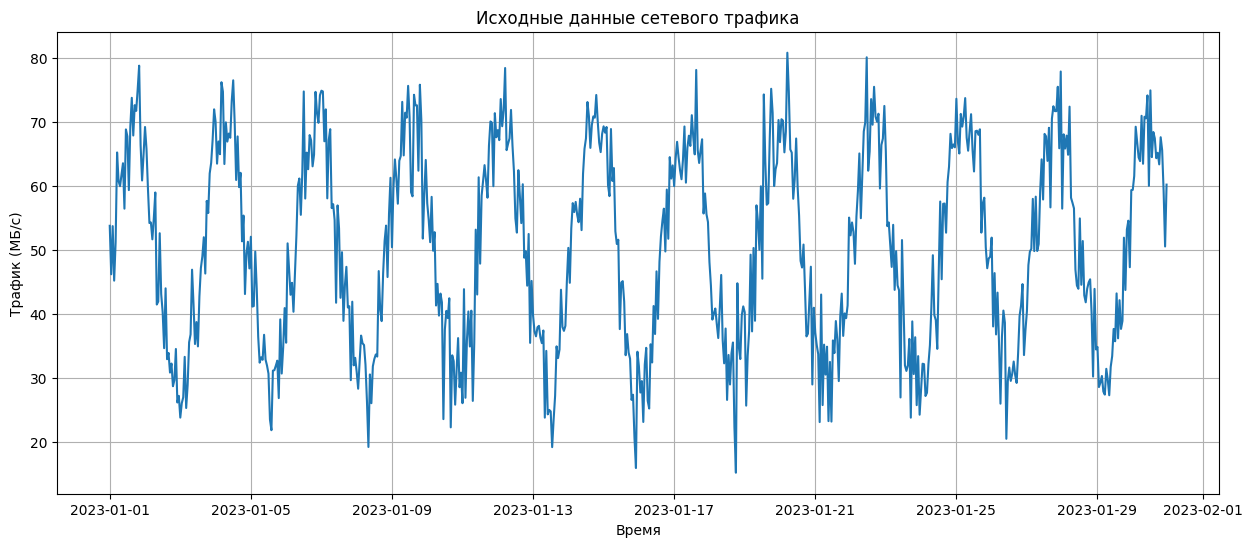

In [7]:
# Визуализация данных
plt.figure(figsize=(15, 6))
plt.plot(df['timestamp'], df['traffic'])
plt.title('Исходные данные сетевого трафика')
plt.xlabel('Время')
plt.ylabel('Трафик (МБ/с)')
plt.grid(True)
plt.show()

In [8]:
# Функция для преобразования данных в формат (X, y)
def create_sequences(data, seq_length):
    """
    Создаёт последовательности для обучения LSTM.
    :param data: нормализованные данные трафика
    :param seq_length: длина входной последовательности (24 часа)
    :return: X — входные последовательности, y — целевые значения
    """
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

In [11]:
# Подготовка данных и модели
def train_model(df, seq_length=24, train_ratio=0.7, val_ratio=0.15):

    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df['traffic'].values.reshape(-1, 1))

    # Создаём последовательности
    X, y = create_sequences(scaled_data, seq_length)

    """
    Подготовка данных для LSTM-модели прогнозирования трафика.
    :param df: DataFrame с колонками 'timestamp' и 'traffic'
    :param seq_length: длина входной последовательности (по умолчанию 24 часа)
    :param train_ratio: доля обучающей выборки
    :param val_ratio: доля валидационной выборки
    :return: словарь с подготовленными данными и скалером
    """

    # Создание последовательностей
    X, y = create_sequences(scaled_data, seq_length)

    # Разбиение на выборки
    split_train = int(train_ratio * len(X))
    split_val = int((train_ratio + val_ratio) * len(X))

    X_train, y_train = X[:split_train], y[:split_train]
    X_val, y_val = X[split_train:split_val], y[split_train:split_val]
    X_test, y_test = X[split_val:], y[split_val:]

    print(f"Форма обучающих данных: X={X_train.shape}, y={y_train.shape}")
    print(f"Форма валидационных данных: X={X_val.shape}, y={y_val.shape}")
    print(f"Форма тестовых данных: X={X_test.shape}, y={y_test.shape}")

    # Строим модель
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])
    print("Архитектура модели создана:")
    model.summary()

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Обучаем

    history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    shuffle=False,  # Важно для временных рядов!
    verbose=1
    )


    # Визуализация процесса обучения
    plt.figure(figsize=(12, 4))

    # График потерь
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Обучающая MSE')
    plt.plot(history.history['val_loss'], label='Валидационная MSE')
    plt.title('Функция потерь (MSE)')
    plt.xlabel('Эпоха')
    plt.ylabel('Потеря')
    plt.legend()

    # График MAE
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Обучающий MAE')
    plt.plot(history.history['val_mae'], label='Валидационный MAE')
    plt.title('Метрика MAE')
    plt.xlabel('Эпоха')
    plt.ylabel('MAE')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Сохраняем данные

    np.save('X_train.npy', X_train)
    np.save('y_train.npy', y_train)
    np.save('X_val.npy', X_val)
    np.save('y_val.npy', y_val)
    np.save('X_test.npy', X_test)
    np.save('y_test.npy', y_test)

    print('Данные сохранены')

    # Сохранение истории обучения для анализа
    np.save('training_history.npy', history)


    print("История обучения сохранена!")

    # Сохраняем модель и скалер
    model.save('lstm_model.keras')
    joblib.dump(scaler, 'scaler.pkl')

    print("Модель обучена и сохранена!")
    return model, scaler

Форма обучающих данных: X=(487, 24, 1), y=(487, 1)
Форма валидационных данных: X=(104, 24, 1), y=(104, 1)
Форма тестовых данных: X=(105, 24, 1), y=(105, 1)
Архитектура модели создана:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 24, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 0.0736 - mae: 0.2217 - val_loss: 0.0425 - val_mae: 0.1727
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0371 - mae: 0.1599 - val_loss: 0.0314 - val_mae: 0.1531
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0297 - mae: 0.1447 - val_loss: 0.0236 - val_mae: 0.1333
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0228 - mae: 0.1267 - val_loss: 0.0162 - val_mae: 0.1064
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0171 - mae: 0.1047 - val_loss: 0.0098 - val_mae: 0.0812
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0129 - mae: 0.0894 - val_loss: 0.0074 - val_mae: 0.0694
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0120 - mae: 0.0870 - val_loss: 0.0074 - val_mae: 0.0690
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0103 - mae: 0.0816 - val_loss: 0.0070 - val_mae: 0.0674
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.010

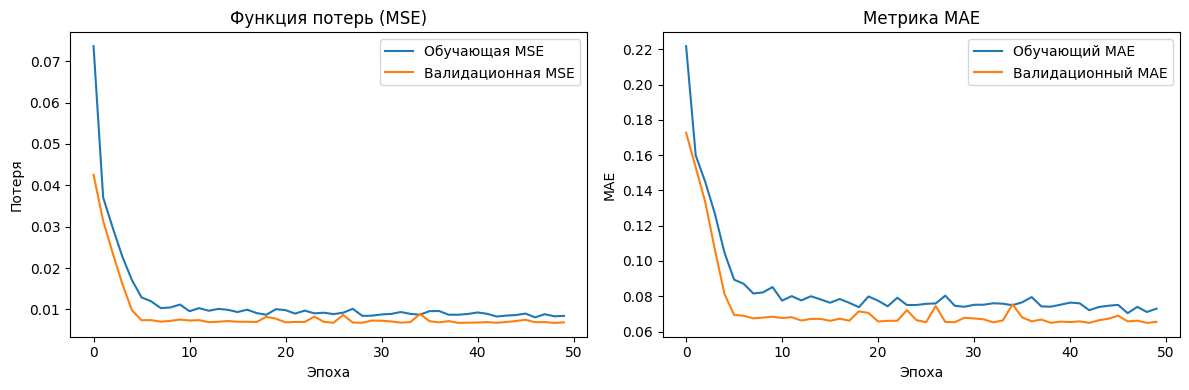

Данные сохранены
История обучения сохранена!
Модель обучена и сохранена!


(<Sequential name=sequential_1, built=True>, MinMaxScaler())

In [12]:
# Обучение модели для прогнозирования сетевого трафика
train_model(df,24,0.7,0.15)

Параметры модели:

shape=(seq_length, 1) — 24 (seq_length=24) временных шага, 1 признак (трафик).

Первый слой LSTM:

50 нейронов — баланс между выразительностью и переобучением;

return_sequences=True — передаём последовательность на следующий LSTM‑слой;

Dropout(0.2): регуляризация, отключает 20 % нейронов для борьбы с переобучением.

Второй слой LSTM:

50 нейронов;

return_sequences=False — возвращаем только последнее состояние для Dense‑слоя.

Dense(25): промежуточный полносвязный слой для нелинейного преобразования.

Dense(1): выходной слой — прогнозирует одно значение трафика.

Оптимизатор adam: адаптивная скорость обучения, хорошо работает «из коробки», подходит для временных рядов.

Функция потерь mean_squared_error (MSE): штрафует за большие ошибки сильнее, чем за малые — критично для трафика, где резкие скачки могут быть важны.

Метрика mean_absolute_error (MAE): показывает среднюю абсолютную ошибку в тех же единицах, что и трафик (МБ/с), удобна для интерпретации.

Эпохи (epochs=50): достаточно для сходимости на синтетических данных. Для реальных данных может потребоваться больше (100–200).

Размер батча (batch_size=32): стандартный выбор, обеспечивает стабильность градиентов.

shuffle=False: сохраняет временную последовательность данных — критически важно для временных рядов, иначе модель «запутается» в порядке событий.

Валидация: используем отдельный набор данных (X_val, y_val) для контроля переобучения.

Тонкая настройка

Если модель переобучается (валидационная ошибка растёт):

увеличить Dropout до 0.3–0.4;

уменьшить число нейронов в LSTM‑слоях (например, до 30);

добавить L1/L2-регуляризацию в слои.

Если модель недообучается (ошибки высокие на обучении и валидации):

увеличить число эпох (до 100–150);

увеличить число нейронов (до 60–80);

добавить ещё один LSTM‑слой.

Для улучшения качества прогноза:

использовать Bidirectional LSTM для учёта контекста «вперёд и назад»;

добавить дополнительные признаки: день недели, время суток, праздники;

попробовать GRU вместо LSTM для ускорения обучения (если точность приемлема).

In [13]:
# Загружаем модель, скалер и данные
model=load_model('lstm_model.keras')
scaler = joblib.load('scaler.pkl')
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

In [14]:
# Оценка модели на тестовой выборке
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"\nРезультаты на тестовой выборке:")
print(f"Тестовая MSE: {test_loss:.6f}")
print(f"Тестовая MAE: {test_mae:.6f} (нормализованные единицы)")


Результаты на тестовой выборке:
Тестовая MSE: 0.006172
Тестовая MAE: 0.065737 (нормализованные единицы)


In [15]:
def plot_predictions(model, scaler):

    # Генерируем тестовые данные

    test_data = np.random.rand(100) * 100  # Искусственные данные
    scaled_data = scaler.transform(test_data.reshape(-1, 1))

    predictions = []
    for i in range(len(scaled_data) - 24):
        X = scaled_data[i:i+24].reshape(1, 24, 1)
        pred_scaled = model.predict(X, verbose=0)
        pred_actual = scaler.inverse_transform(pred_scaled)[0][0]
        predictions.append(pred_actual)

    # Строим график
    plt.figure(figsize=(12, 6))
    plt.plot(test_data[24:], label='Фактические данные', alpha=0.7)
    plt.plot(predictions, label='Прогнозы модели', linewidth=2)
    plt.title('Сравнение фактических данных и прогнозов LSTM-модели')
    plt.xlabel('Временные шаги')
    plt.ylabel('Значение трафика')
    plt.legend()
    plt.grid(True)
    plt.savefig('predictions_plot.png')
    plt.show()


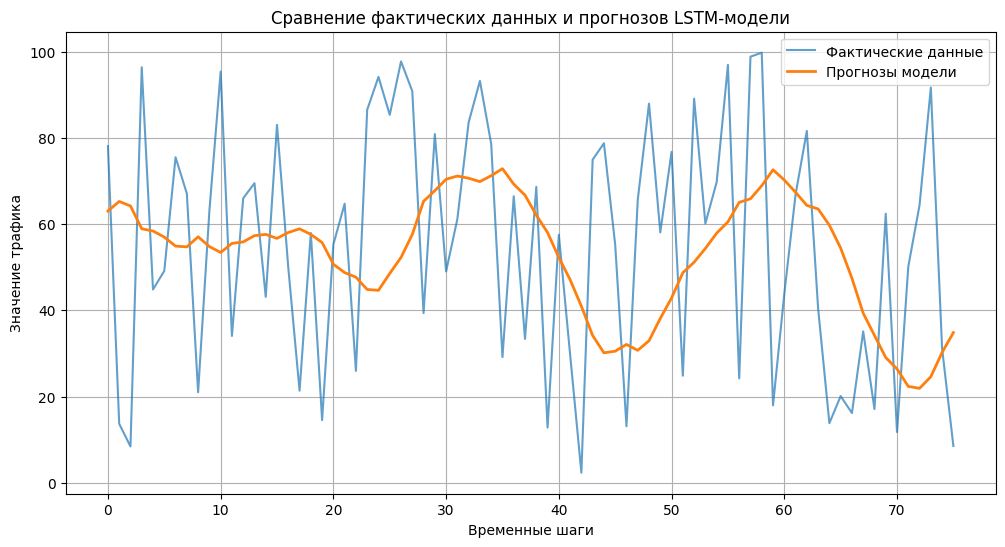

In [16]:
plot_predictions(model,scaler)

In [17]:
def inverse_transform_predictions(predictions, scaler):
    """
    Обратное преобразование для любого числа признаков.
    """
    if predictions.ndim == 1:
        predictions = predictions.reshape(-1, 1)
    real_predictions = scaler.inverse_transform(predictions)
    return real_predictions.flatten() if real_predictions.shape[1] == 1 else real_predictions

In [18]:
# Прогнозы на тестовой выборке
predictions = model.predict(X_test)

# Обратное преобразование в реальные единицы (МБ/с)
real_predictions = inverse_transform_predictions(predictions, scaler)
real_actual = inverse_transform_predictions(y_test, scaler)

print(f"Первые 10 прогнозов (МБ/с): {real_predictions[:10]}")
print(f"Первые 10 фактических значений (МБ/с): {real_actual[:10]}")

# Расчёт метрик качества в реальных единицах
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse_real = mean_squared_error(real_actual, real_predictions)
mae_real = mean_absolute_error(real_actual, real_predictions)
r2_real = r2_score(real_actual, real_predictions)

print(f"\nМетрики качества в реальных единицах (МБ/с):")
print(f"MSE: {mse_real:.4f}")
print(f"MAE: {mae_real:.4f}")
print(f"R²: {r2_real:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step 
Первые 10 прогнозов (МБ/с): [29.904137 30.594358 31.433317 31.918705 32.898323 34.514957 36.44501
 38.81772  40.755806 42.504787]
Первые 10 фактических значений (МБ/с): [32.61070705 30.51259576 29.27108023 33.88859223 39.73835776 41.34444829
 44.7061933  33.62369731 37.50480736 40.47792216]

Метрики качества в реальных единицах (МБ/с):
MSE: 26.5622
MAE: 4.3124
R²: 0.8702


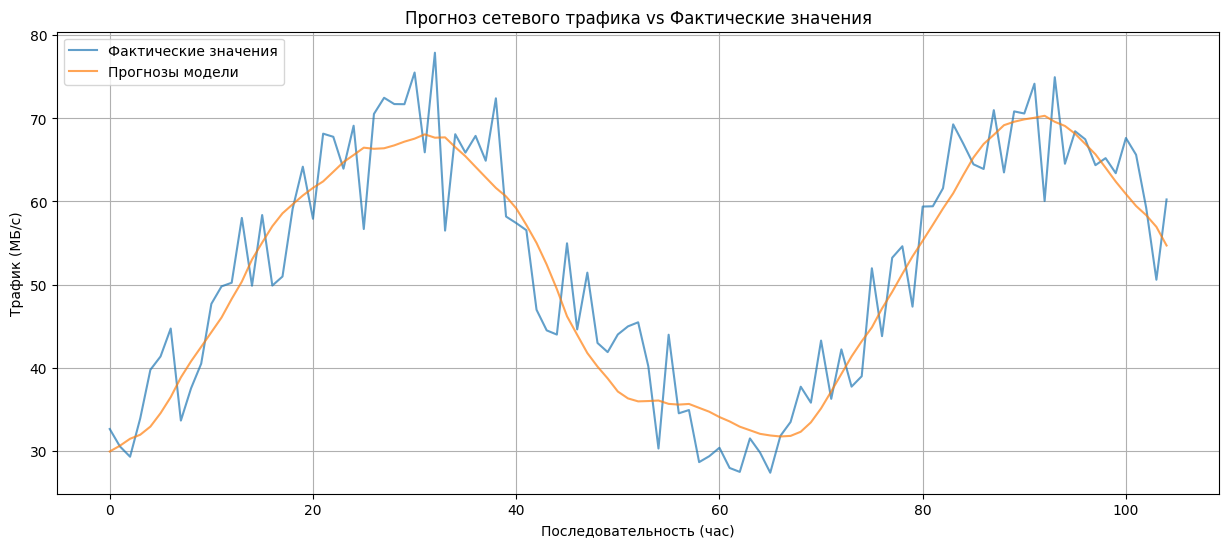

In [19]:
# Визуализация прогнозов vs фактических значений
plt.figure(figsize=(15, 6))
plt.plot(real_actual, label='Фактические значения', alpha=0.7)
plt.plot(real_predictions, label='Прогнозы модели', alpha=0.7)
plt.title('Прогноз сетевого трафика vs Фактические значения')
plt.xlabel('Последовательность (час)')
plt.ylabel('Трафик (МБ/с)')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
def predict_next_hour(model, scaler, last_24_hours):
    """
    Прогнозирует трафик на следующий час.
    :param model: обученная LSTM‑модель
    :param scaler: обученный скалер
    :param last_24_hours: массив из 24 последних значений трафика
    :return: прогноз на следующий час в МБ/с
    """
    # Шаг 1. Валидация входных данных
    if not isinstance(last_24_hours, (list, np.ndarray)):
        raise ValueError("last_24_hours должен быть списком или numpy array")

    last_24_hours = np.array(last_24_hours)

    if len(last_24_hours) != 24:
        raise ValueError(f"Ожидалось 24 значения, получено {len(last_24_hours)}")

    # Шаг 2. Проверка на проблемные значения
    if np.isnan(last_24_hours).any():
        raise ValueError("Входные данные содержат NaN значения")

    if np.isinf(last_24_hours).any():
        raise ValueError("Входные данные содержат бесконечные значения")

    # Шаг 3. Приведение к корректному типу
    last_24_hours = last_24_hours.astype(np.float32)

    # Шаг 4. Нормализация
    try:
        scaled_input = scaler.transform(last_24_hours.reshape(-1, 1)).flatten()
    except Exception as e:
        raise ValueError(f"Ошибка нормализации: {e}")

    # Шаг 5. Подготовка для LSTM: (1, 24, 1)
    X_input = scaled_input.reshape(1, 24, 1)

    # Шаг 6. Проверка формы перед прогнозом
    assert X_input.shape == (1, 24, 1), f"Неверная форма входных данных: {X_input.shape}"

    # Шаг 7. Прогноз
    prediction_scaled = model.predict(X_input, verbose=0)[0][0]

    # Шаг 8. Обратное преобразование
    prediction_2d = np.array([[prediction_scaled]], dtype=np.float32)
    prediction_real = scaler.inverse_transform(prediction_2d)[0, 0]

    return float(prediction_real)

In [21]:
# прогноз на следующий час с подробной диагностикой
def safe_predict_next_hour(model, scaler, data_source, hours_back=24):

    try:
        # Получаем последние 24 часа
        if isinstance(data_source, pd.DataFrame):
            last_24_hours = data_source['traffic'].values[-hours_back:]
        else:
            last_24_hours = data_source[-hours_back:]

        # Выполняем прогноз
        prediction = predict_next_hour(model, scaler, last_24_hours)
        print(f"✅ Прогноз трафика на следующий час: {prediction:.2f} МБ/с")
        return prediction

    except ValueError as e:
        print(f"❌ Ошибка в данных: {e}")
        return None
    except Exception as e:
        print(f"❌ Неожиданная ошибка: {e}")
        return None

# Использование
sample_input = df['traffic'].values[-24:]
next_hour_prediction = safe_predict_next_hour(model, scaler, sample_input)

✅ Прогноз трафика на следующий час: 53.04 МБ/с


web-API

In [22]:
# Настройка логирования
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Глобальные переменные для модели и скалера
model = None
scaler = None

@asynccontextmanager
async def lifespan(app: FastAPI):
    """
    Обработчик жизненного цикла приложения.
    Заменяет устаревший @app.on_event("startup"/"shutdown").
    """
    # Код при запуске
    global model, scaler
    try:
        model = load_model('lstm_model.keras')
        scaler = joblib.load('scaler.pkl')
        logger.info("Модель и скалер успешно загружены")
    except Exception as e:
        logger.error(f"Ошибка загрузки модели/скалера: {e}")
        raise

    yield  # Здесь приложение работает

    # Код при завершении (опционально)
    logger.info("Приложение завершает работу")

app = FastAPI(title="Traffic Prediction API", version="1.0.0", lifespan=lifespan)

class PredictionRequest(BaseModel):
    historical_data: list[float]  # Последние 24 значения трафика

class PredictionResponse(BaseModel):
    prediction: float
    timestamp: str
    success: bool = True

@app.post("/predict", response_model=PredictionResponse)
async def predict(request: PredictionRequest):
    """Прогнозирует трафик на следующий час на основе последних 24 часов данных."""
    try:
        # Валидация входных данных
        if len(request.historical_data) != 24:
            raise HTTPException(
                status_code=400,
                detail=f"Ожидалось 24 значения, получено {len(request.historical_data)}"
            )

        # Проверка на NaN и бесконечности
        data_array = np.array(request.historical_data)
        if np.isnan(data_array).any():
            raise HTTPException(status_code=400, detail="Данные содержат NaN значения")
        if np.isinf(data_array).any():
            raise HTTPException(status_code=400, detail="Данные содержат бесконечные значения")

        # Обрабатываем входные данные
        data = data_array.reshape(-1, 1).astype(np.float32)
        scaled_data = scaler.transform(data)
        X = scaled_data.reshape(1, 24, 1)  # Формируем последовательность

        # Делаем прогноз
        prediction_scaled = model.predict(X, verbose=0)
        prediction_actual = scaler.inverse_transform(prediction_scaled)[0][0]

        return PredictionResponse(
            prediction=float(prediction_actual),
            timestamp=datetime.now().isoformat(),
            success=True
        )
    except HTTPException as e:
        raise e
    except Exception as e:
        logger.error(f"Ошибка в прогнозировании: {e}")
        raise HTTPException(
            status_code=500,
            detail=f"Внутренняя ошибка сервера: {str(e)}"
        )

@app.get("/health")
async def health():
    """Проверка здоровья API."""
    try:
        test_input = np.random.uniform(0.1, 1.0, size=(1, 24, 1)).astype(np.float32)
        _ = model.predict(test_input, verbose=0)
        return {"status": "healthy", "model_loaded": True}
    except:
        return {"status": "unhealthy", "model_loaded": False}

@app.get("/")
async def root():
    """Главная страница API."""
    return {
        "message": "Traffic Prediction API работает!",
        "endpoints": {
            "/predict": "POST — прогноз трафика",
            "/health": "GET — проверка здоровья",
            "/docs": "GET — интерактивная документация (Swagger UI)"
        }
    }

In [23]:
import threading
def run_server():
    uvicorn.run(app, host="127.0.0.1", port=8000)

# Запускаем сервер в отдельном потоке
server_thread = threading.Thread(target=run_server)
server_thread.daemon = True
server_thread.start()

print("=" * 50)
print("✅ API ЗАПУЩЕН В COLAB")
print("=" * 50)
print("🌐 Локальный URL: http://127.0.0.1:8000")
print("📝 Документация API: http://127.0.0.1:8000/docs")
print("💓 Проверка здоровья: http://127.0.0.1:8000/health")
print("=" * 50)

✅ API ЗАПУЩЕН В COLAB
🌐 Локальный URL: http://127.0.0.1:8000
📝 Документация API: http://127.0.0.1:8000/docs
💓 Проверка здоровья: http://127.0.0.1:8000/health


In [30]:
import requests
import json

# Тестовые данные
test_data = {
    "historical_data": [
        100.5, 102.3, 98.7, 110.2, 105.8,
        99.1, 103.4, 107.6, 101.9, 97.3,
        112.5, 108.7, 95.2, 104.8, 106.1,
        98.9, 102.7, 109.3, 100.8, 96.4,
        105.2, 103.9, 99.7, 107.1
    ]
}

# Отправляем запрос
try:
    response = requests.post("http://127.0.0.1:8000/predict", json=test_data)
    if response.status_code == 200:
        result = response.json()
        print("✅ Успешный прогноз:")
        print(json.dumps(result, indent=2, ensure_ascii=False))
    else:
        print(f"❌ Ошибка: {response.status_code}")
        print(response.json())
except Exception as e:
    print(f"❌ Ошибка запроса: {e}")

INFO:     127.0.0.1:44034 - "POST /predict HTTP/1.1" 200 OK
✅ Успешный прогноз:
{
  "prediction": 74.40828704833984,
  "timestamp": "2026-03-10T11:03:07.182189",
  "success": true
}


In [26]:
import requests

class APIClient:
    def __init__(self, base_url="http://localhost:8000"):
        self.base_url = base_url
        self.session = requests.Session()

    def check_health(self):
        """Проверяет доступность API"""
        try:
            response = self.session.get(f"{self.base_url}/health", timeout=5)
            if response.status_code == 200:
                print("✅ API доступно и работает корректно")
                return True
            else:
                print(f"⚠️ API вернуло статус {response.status_code}")
                return False
        except Exception as e:
            print(f"❌ API недоступно: {e}")
            return False

    def get_prediction(self, historical_data):
        """Получает прогноз от API"""
        url = f"{self.base_url}/predict"
        payload = {"historical_data": historical_data}

        try:
            response = self.session.post(url, json=payload, timeout=10)
            if response.status_code == 200:
                return response.json()
            else:
                raise Exception(f"Ошибка API: {response.status_code} — {response.text}")
        except Exception as e:
            raise Exception(f"Ошибка запроса: {e}")

    def interactive_mode(self):
        """Интерактивный режим ввода данных"""
        print("=== Клиент API для прогнозирования трафика ===")
        print("Для выхода введите 'quit' или 'exit'\n")

        while True:
            try:
                # Ввод данных
                user_input = input("Введите 24 значения трафика через запятую: ")

                if user_input.lower() in ['quit', 'exit']:
                    print("До свидания!")
                    break  # ← теперь break внутри цикла

                # Обработка ввода
                data_str = user_input.strip().split(',')
                historical_data = [float(x.strip()) for x in data_str]

                if len(historical_data) != 24:
                    print(f"⚠️ Ошибка: нужно ровно 24 значения, вы ввели {len(historical_data)}")
                    continue  # ← теперь continue внутри цикла

                # Получение прогноза
                print("Отправляю запрос к API...")
                result = self.get_prediction(historical_data)

                # Вывод результата
                print(f"\n📊 РЕЗУЛЬТАТ ПРОГНОЗА")
                print(f"Прогноз: {result['prediction']:.2f} МБ/с")
                print(f"Время: {result['timestamp']}")
                print("-!" * 40)

            except ValueError:
                print("⚠️ Ошибка: введите числа через запятую")
            except Exception as e:
                print(f"❌ Ошибка: {e}")

In [27]:
client = APIClient()
if client.check_health():
    client.interactive_mode()
else:
    print("API недоступно")

INFO:     127.0.0.1:37606 - "GET /health HTTP/1.1" 200 OK
✅ API доступно и работает корректно
=== Клиент API для прогнозирования трафика ===
Для выхода введите 'quit' или 'exit'

Введите 24 значения трафика через запятую: 1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
Отправляю запрос к API...
INFO:     127.0.0.1:55232 - "POST /predict HTTP/1.1" 200 OK

📊 РЕЗУЛЬТАТ ПРОГНОЗА
Прогноз: 39.48 МБ/с
Время: 2026-03-10T11:01:11.328133
-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!
Введите 24 значения трафика через запятую:  34,55,66,77,88,99,98,87,76,65,54,43,32,34,23,45,56,67,78,89,76,45,66,34
Отправляю запрос к API...
INFO:     127.0.0.1:60808 - "POST /predict HTTP/1.1" 200 OK

📊 РЕЗУЛЬТАТ ПРОГНОЗА
Прогноз: 49.15 МБ/с
Время: 2026-03-10T11:02:03.547909
-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!-!
Введите 24 значения трафика через запятую: exit
До свидания!


In [28]:
import requests
import matplotlib.pyplot as plt

class VisualAPIClient(APIClient):
    def plot_prediction(self, historical_data, prediction):
        """Строит график с историческими данными и прогнозом"""
        # Создаём данные для графика
        all_data = historical_data + [prediction]
        labels = list(range(-24, 1))  # [-24, -23, ..., 0, +1]

        plt.figure(figsize=(12, 6))

        # Исторические данные
        plt.plot(labels[:-1], historical_data,
                   label='Исторические данные',
                   marker='o',
                   linewidth=2,
                   markersize=4)

        # Прогноз
        plt.scatter(labels[-1], prediction,
                    color='red',
            label='Прогноз',
            s=100,
            zorder=5)

        plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5,
                 label='Текущий момент')

        plt.title('Прогноз сетевого трафика')
        plt.xlabel('Часы относительно текущего момента')
        plt.ylabel('Трафик (МБ/с)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def run_with_visualization(self):
        """Запуск с визуализацией"""
        print("=== Визуальный клиент API ===")

        # Ввод данных
        user_input = input("Введите 24 значения трафика через запятую: ")
        data_str = user_input.strip().split(',')
        historical_data = [float(x.strip()) for x in data_str]

        if len(historical_data) != 24:
            print(f"Ошибка: нужно ровно 24 значения")
            return

        # Получение прогноза
        result = self.get_prediction(historical_data)

        # Вывод результата и построение графика
        print(f"\n📊 РЕЗУЛЬТАТ:")
        print(f"Прогноз: {result['prediction']:.2f} МБ/с")
        print(f"Время: {result['timestamp']}")

        self.plot_prediction(historical_data, result['prediction'])



INFO:     127.0.0.1:38206 - "GET /health HTTP/1.1" 200 OK
✅ API доступно и работает корректно
=== Визуальный клиент API ===
Введите 24 значения трафика через запятую:  34,55,66,77,88,99,98,87,76,65,54,43,32,34,23,45,56,67,78,89,76,45,66,34
INFO:     127.0.0.1:38222 - "POST /predict HTTP/1.1" 200 OK

📊 РЕЗУЛЬТАТ:
Прогноз: 49.15 МБ/с
Время: 2026-03-10T11:02:29.565257


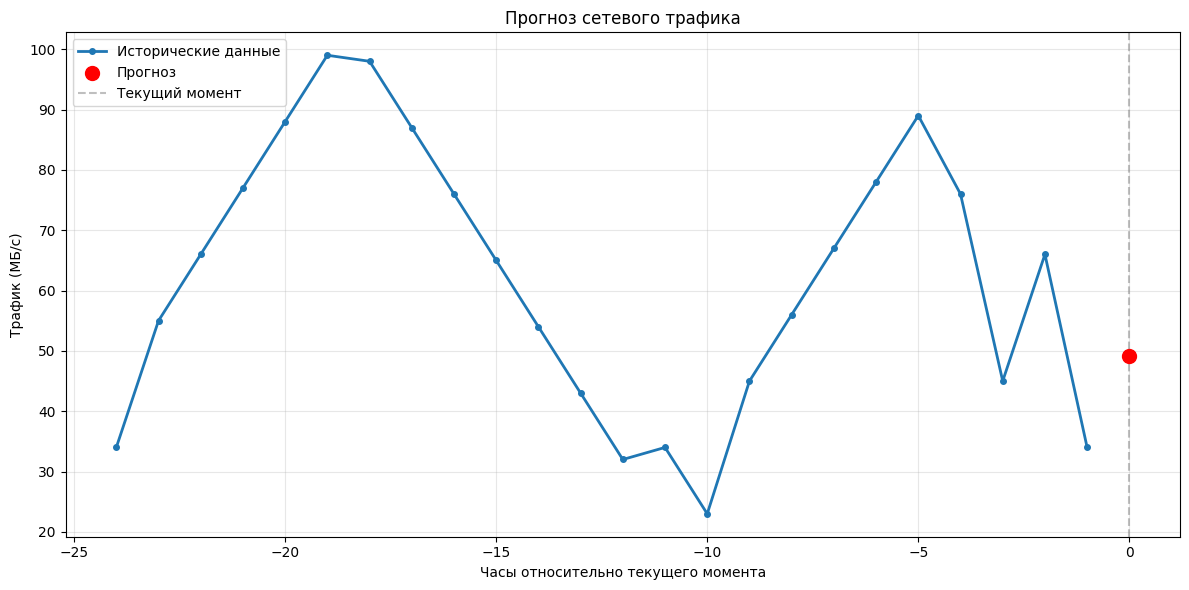

In [29]:
client = VisualAPIClient()

if client.check_health():
    client.run_with_visualization()